<a href="https://colab.research.google.com/github/Mauricio-Fragoso-Mendoza/Simulacion-I/blob/main/C%C3%B3digo%201%3A%20L%C3%ADnea%20de%20Espera%20con%20dos%20Servidores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random as r
import math as m
import matplotlib.pyplot as plt

**En Serie:** Los elementos ocupados en este sistema son

$t$: Tiempo

$n_1$: Número de clientes en el servidor 1

$n_2$: Número de clientes en el servidor 2

*Variables de conteo:*

$N_A$: Número de llegadas hasta el instante $t$

$N_D$: Número de salidas hasta el instante $t$

*Varialbes de salida:*

$A_1(n)$: Hora de llegada del cliente n al servidor 1, $n \geq 1$

$A_2(n)$: Hora de llegada del cliente n al servidor 2, $n \geq 1$

$D(n)$: Hora de salida del cliente n, $n \geq 1$

Generar $T_0 \rightarrow U \backsim U(0,1)$
$$t=0$$
$$t_A=T_0$$
$$t_1=t_2=\infty$$

In [4]:
def LE2S(n1,n2,T):
  t=0
  S=[]
  NA=0
  AS1=[]
  AS2=[]
  ND=0
  DS=[]

  #Inicialización
  T0=r.random()
  tA=T0
  t1=m.inf
  t2=m.inf

  if tA==min(tA,t1,t2):
    t=tA
    NA=NA+1
    n1=n1+1
    Tr=r.random()
    tA=Tr
    if n1==1:
      Y1=r.random()
      t1=t+Y1
    AS1.append(t)

  if t1<tA and t1<=t2:
    t=t1
    n1=n1-1
    n2=n2+1
    if n1==0:
      t1=m.inf
    else:
      Y1=r.random()
      t1=t+Y1
    if n2==1:
      Y2=r.random()
      t2=t+Y2
    AS2.append(t)

  if t2<tA and t2<=t1:
    t=t2
    ND=ND+1
    n2=n2-1
    if n2==0:
      t2=m.inf
    if n2>0:
      Y2=r.random()
      t2=t+Y2
    DS.append(t)

  return S,AS1,AS2,DS

In [5]:
Serie = LE2S(10,12,6)

In [6]:
Serie

([], [0.5658595207748545], [], [])

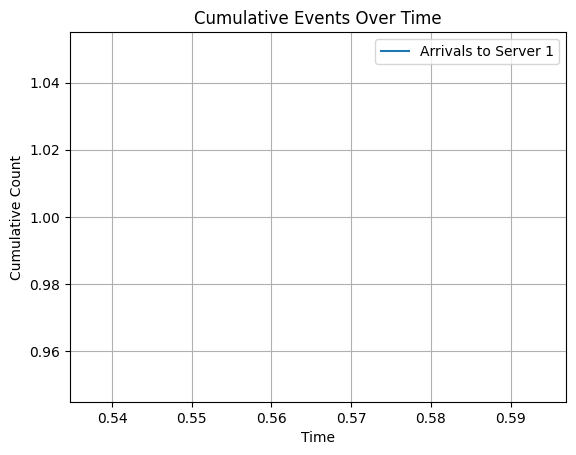

In [8]:
if Serie[1]: # Plot AS1 (Arrivals to Server 1)
  x_as1 = sorted(Serie[1])
  y_as1 = np.arange(1, len(x_as1) + 1)
  plt.step(x_as1, y_as1, label='Arrivals to Server 1')

if Serie[2]: # Plot AS2 (Arrivals to Server 2)
  x_as2 = sorted(Serie[2])
  y_as2 = np.arange(1, len(x_as2) + 1)
  plt.step(x_as2, y_as2, label='Arrivals to Server 2')

if Serie[3]: # Plot DS (Departures)
  x_ds = sorted(Serie[3])
  y_ds = np.arange(1, len(x_ds) + 1)
  plt.step(x_ds, y_ds, label='Departures')

plt.xlabel('Time')
plt.ylabel('Cumulative Count')
plt.title('Cumulative Events Over Time')
plt.legend()
plt.grid(True)
plt.show()

**En Paralelo:** Los elementos a utilizar son

$t$: Tiempo

*Variable de Estado del Sistema (ES):* $(n,i_1,i_2,...,i_n)$ si hay $n$ clientes en el sistema, $i_1$ está con el servidor 1, $i_2$ está con el servidor 2, $i_3$ es el primero de la fila, $i_4$ es el siguiente, y así sucesivamente.

*Sistema vacío:* $ES=(0)$

*Cliente j (único) atendido por el servidor 1:* $ES=(1,j,0)$

*Cliente j (único) atendido por el servidor 2:* $ES=(1,0,j)$


*Variables de conteo:*

$N_A$: Número de llegadas hasta el instante $t$

$C_j$: Número de clientes atendidos por $j$, $j=1,2$, hasta el instante $t$

*Varialbes de salida:*

$A(n)$: Hora de llegada del cliente $n$, $n \geq 1$

$D(n)$: Hora de salida del cliente $n$, $n \geq 1$

*Lista de elementos:*

$t_A$: Hora de la siguiente llegada

$t_1$ es la hora en la que concluye el servicio del cliente que en este momento está siendo atendido por el servidor $i$, $i=1,2$. Si no hay un cliente actualmente con el servidor $i$, entonces $t_i=\infty$, $i=1,2$